In [3]:
import pandas as pd

# ratings.dat 的分隔符是 ::，pandas 需要指定
ratings = pd.read_csv(
    "../data/ml-1m/ratings.dat",
    sep="::",
    names=["user_id", "movie_id", "rating", "timestamp"],
    engine="python"
)

movies = pd.read_csv(
    "../data/ml-1m/movies.dat",
    sep="::",
    names=["movie_id", "title", "genres"],
    engine="python",
    encoding="latin-1"
)

users = pd.read_csv(
    "../data/ml-1m/users.dat",
    sep="::",
    names=["user_id", "gender", "age", "occupation", "zip"],
    engine="python"
)

print("=== ratings ===")
print(ratings.shape)
print(ratings.head())
print(ratings["rating"].value_counts().sort_index())

print("\n=== movies ===")
print(movies.shape)
print(movies.head())

print("\n=== users ===")
print(users.shape)
print(users.head())

=== ratings ===
(1000209, 4)
   user_id  movie_id  rating  timestamp
0        1      1193       5  978300760
1        1       661       3  978302109
2        1       914       3  978301968
3        1      3408       4  978300275
4        1      2355       5  978824291
rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64

=== movies ===
(3883, 3)
   movie_id                               title                        genres
0         1                    Toy Story (1995)   Animation|Children's|Comedy
1         2                      Jumanji (1995)  Adventure|Children's|Fantasy
2         3             Grumpier Old Men (1995)                Comedy|Romance
3         4            Waiting to Exhale (1995)                  Comedy|Drama
4         5  Father of the Bride Part II (1995)                        Comedy

=== users ===
(6040, 5)
   user_id gender  age  occupation    zip
0        1      F    1          10  48067
1        2      M   56          16 

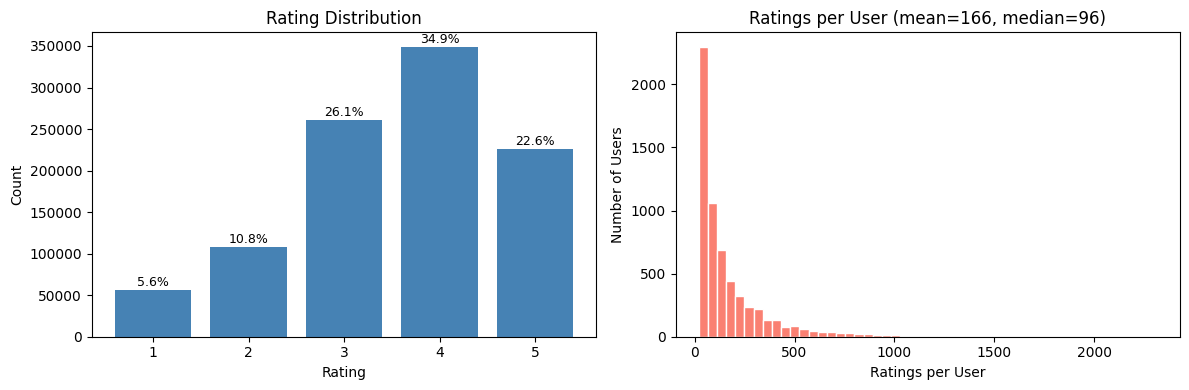

总评分数：1,000,209
用户数：6,040
电影数：3,706
评分最少的用户打了 20 条，最多的打了 2314 条


In [4]:
import matplotlib.pyplot as plt

# 评分分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图：评分值分布（1-5星）
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('Rating Distribution')
for i, (k, v) in enumerate(rating_counts.items()):
    axes[0].text(k, v + 5000, f'{v/len(ratings)*100:.1f}%', ha='center', fontsize=9)

# 右图：每个用户的评分数量分布
user_rating_counts = ratings.groupby('user_id')['rating'].count()
axes[1].hist(user_rating_counts, bins=50, color='salmon', edgecolor='white')
axes[1].set_xlabel('Ratings per User')
axes[1].set_ylabel('Number of Users')
axes[1].set_title(f'Ratings per User (mean={user_rating_counts.mean():.0f}, median={user_rating_counts.median():.0f})')

plt.tight_layout()
plt.show()

print(f"总评分数：{len(ratings):,}")
print(f"用户数：{ratings['user_id'].nunique():,}")
print(f"电影数：{ratings['movie_id'].nunique():,}")
print(f"评分最少的用户打了 {user_rating_counts.min()} 条，最多的打了 {user_rating_counts.max()} 条")

用户-电影矩阵大小：6040 x 3706 = 22,384,240 个格子
已填写：1,000,209 个
稠密度：4.4684%  （即 95.53% 是空的）


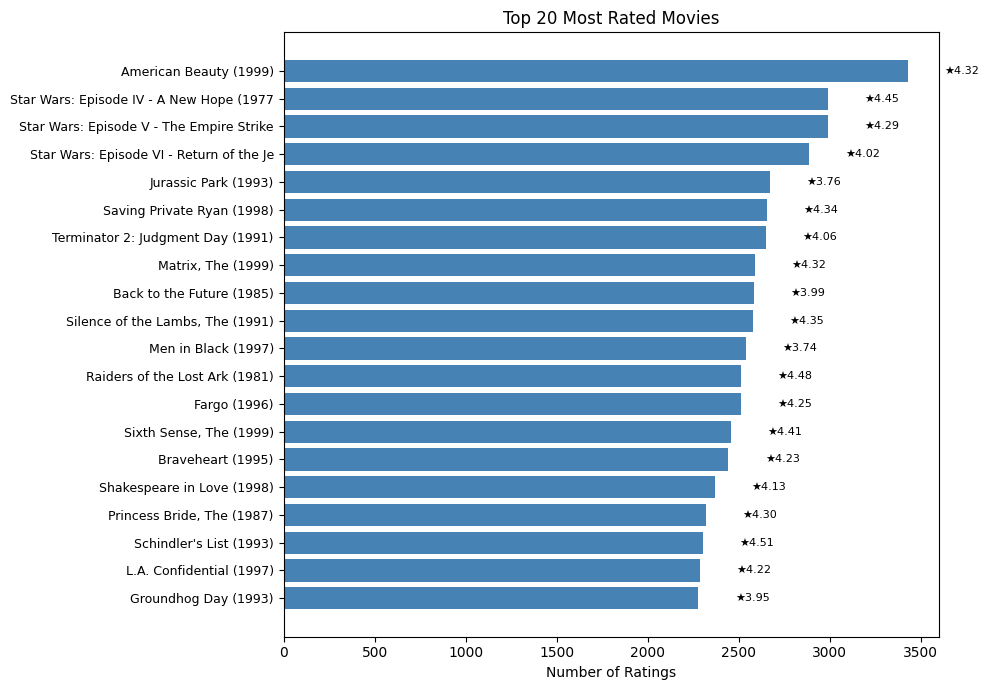

In [5]:
# 矩阵稠密度
n_users = ratings['user_id'].nunique()
n_movies = ratings['movie_id'].nunique()
n_ratings = len(ratings)
density = n_ratings / (n_users * n_movies)

print(f"用户-电影矩阵大小：{n_users} x {n_movies} = {n_users * n_movies:,} 个格子")
print(f"已填写：{n_ratings:,} 个")
print(f"稠密度：{density:.4%}  （即 {100-density*100:.2f}% 是空的）")

# 热门电影 Top 20
movie_stats = ratings.groupby('movie_id').agg(
    rating_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

movie_stats = movie_stats.merge(movies[['movie_id', 'title']], on='movie_id')
top20 = movie_stats.sort_values('rating_count', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(range(20), top20['rating_count'].values, color='steelblue')
ax.set_yticks(range(20))
ax.set_yticklabels([t[:40] for t in top20['title'].values], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Number of Ratings')
ax.set_title('Top 20 Most Rated Movies')

# 在每条 bar 右侧显示平均分
for i, (count, avg) in enumerate(zip(top20['rating_count'], top20['avg_rating'])):
    ax.text(count + 200, i, f'★{avg:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [6]:
import torch
import numpy as np

# 把 user_id / movie_id 映射到连续整数（0-based），作为 embedding 的下标
user2idx = {uid: idx for idx, uid in enumerate(ratings['user_id'].unique())}
movie2idx = {mid: idx for idx, mid in enumerate(ratings['movie_id'].unique())}

ratings['user_idx'] = ratings['user_id'].map(user2idx)
ratings['movie_idx'] = ratings['movie_id'].map(movie2idx)

n_users = len(user2idx)
n_movies = len(movie2idx)
print(f"用户数：{n_users}，电影数：{n_movies}")

# 训练/验证集切分（按时间戳，模拟真实场景）
ratings_sorted = ratings.sort_values('timestamp')
split = int(len(ratings_sorted) * 0.9)
train_df = ratings_sorted.iloc[:split]
val_df   = ratings_sorted.iloc[split:]
print(f"训练集：{len(train_df):,}，验证集：{len(val_df):,}")

# 转成 tensor
def df_to_tensors(df):
    users   = torch.tensor(df['user_idx'].values, dtype=torch.long)
    movies  = torch.tensor(df['movie_idx'].values, dtype=torch.long)
    ratings_val = torch.tensor(df['rating'].values, dtype=torch.float32)
    return users, movies, ratings_val

train_users, train_movies, train_ratings = df_to_tensors(train_df)
val_users,   val_movies,   val_ratings   = df_to_tensors(val_df)

print(f"\ntrain_users shape: {train_users.shape}")
print(f"rating 范围: {train_ratings.min().item()} ~ {train_ratings.max().item()}")

用户数：6040，电影数：3706
训练集：900,188，验证集：100,021

train_users shape: torch.Size([900188])
rating 范围: 1.0 ~ 5.0


In [7]:
import torch.nn as nn

class MatrixFactorization(nn.Module):
    def __init__(self, n_users, n_movies, emb_dim=64):
        super().__init__()
        # 每个用户/电影各一个 emb_dim 维向量
        self.user_emb  = nn.Embedding(n_users,  emb_dim)
        self.movie_emb = nn.Embedding(n_movies, emb_dim)
        # bias：每个用户有自己的评分基准（有人习惯打高分），每部电影也有
        self.user_bias  = nn.Embedding(n_users,  1)
        self.movie_bias = nn.Embedding(n_movies, 1)

        # 初始化：小随机数，bias 初始化为 0
        nn.init.normal_(self.user_emb.weight,  std=0.01)
        nn.init.normal_(self.movie_emb.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)

    def forward(self, user_idx, movie_idx):
        u = self.user_emb(user_idx)           # [B, emb_dim]
        m = self.movie_emb(movie_idx)         # [B, emb_dim]
        dot = (u * m).sum(dim=1)              # [B]  点积

        ub = self.user_bias(user_idx).squeeze()   # [B]
        mb = self.movie_bias(movie_idx).squeeze()  # [B]

        score = dot + ub + mb
        # 把输出 clamp 到 [1, 5]，符合评分范围
        return score.clamp(1.0, 5.0)

model = MatrixFactorization(n_users, n_movies, emb_dim=64)
print(model)
print(f"\n可训练参数：{sum(p.numel() for p in model.parameters()):,}")

# 验证 forward 能跑通
dummy_u = torch.tensor([0, 1, 2])
dummy_m = torch.tensor([0, 1, 2])
out = model(dummy_u, dummy_m)
print(f"dummy output: {out}")

MatrixFactorization(
  (user_emb): Embedding(6040, 64)
  (movie_emb): Embedding(3706, 64)
  (user_bias): Embedding(6040, 1)
  (movie_bias): Embedding(3706, 1)
)

可训练参数：633,490
dummy output: tensor([1., 1., 1.], grad_fn=<ClampBackward1>)


In [8]:
from torch.utils.data import TensorDataset, DataLoader

# DataLoader
train_ds = TensorDataset(train_users, train_movies, train_ratings)
val_ds   = TensorDataset(val_users,   val_movies,   val_ratings)
train_loader = DataLoader(train_ds, batch_size=2048, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=2048, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_n = 0.0, 0
    with torch.set_grad_enabled(train):
        for u, m, r in loader:
            pred = model(u, m)
            loss = loss_fn(pred, r)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(r)
            total_n    += len(r)
    return (total_loss / total_n) ** 0.5   # 返回 RMSE

print("Epoch | Train RMSE | Val RMSE")
print("-" * 35)
for epoch in range(1, 11):
    train_rmse = run_epoch(train_loader, train=True)
    val_rmse   = run_epoch(val_loader,   train=False)
    print(f"  {epoch:2d}  |   {train_rmse:.4f}   |  {val_rmse:.4f}")

Epoch | Train RMSE | Val RMSE
-----------------------------------
   1  |   2.8224   |  2.7257
   2  |   2.8224   |  2.7257
   3  |   2.8224   |  2.7257
   4  |   2.8224   |  2.7257
   5  |   2.8224   |  2.7257
   6  |   2.8224   |  2.7257
   7  |   2.8224   |  2.7257
   8  |   2.8224   |  2.7257
   9  |   2.8224   |  2.7257
  10  |   2.8224   |  2.7257


In [9]:
# 取一个 mini-batch 手动走一步，检查梯度
model.train()
u, m, r = next(iter(train_loader))
pred = model(u, m)
print(f"pred 前5个: {pred[:5]}")
print(f"real 前5个: {r[:5]}")

loss = loss_fn(pred, r)
print(f"loss: {loss.item()}")

optimizer.zero_grad()
loss.backward()

# 检查 embedding 的梯度是否存在
print(f"\nuser_emb.weight.grad 是否为 None: {model.user_emb.weight.grad is None}")
print(f"user_bias.weight.grad 是否为 None: {model.user_bias.weight.grad is None}")

# 检查 pred 是否全是 1.0（clamp 到下界导致梯度消失）
print(f"\npred 全部等于 1.0？ {(pred == 1.0).all().item()}")
print(f"pred 的范围: {pred.min().item():.4f} ~ {pred.max().item():.4f}")

pred 前5个: tensor([1., 1., 1., 1., 1.], grad_fn=<SliceBackward0>)
real 前5个: tensor([4., 4., 3., 4., 4.])
loss: 7.9111328125

user_emb.weight.grad 是否为 None: False
user_bias.weight.grad 是否为 None: False

pred 全部等于 1.0？ True
pred 的范围: 1.0000 ~ 1.0000


In [10]:
# 重新初始化模型，bias 用全局平均分初始化
model = MatrixFactorization(n_users, n_movies, emb_dim=64)

global_mean = train_ratings.mean().item()
print(f"训练集平均分：{global_mean:.4f}")

nn.init.constant_(model.user_bias.weight,  0.0)
nn.init.constant_(model.movie_bias.weight, 0.0)

# 去掉 clamp，改在 forward 外处理
class MatrixFactorization(nn.Module):
    def __init__(self, n_users, n_movies, emb_dim=64):
        super().__init__()
        self.user_emb   = nn.Embedding(n_users,  emb_dim)
        self.movie_emb  = nn.Embedding(n_movies, emb_dim)
        self.user_bias  = nn.Embedding(n_users,  1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.global_bias = nn.Parameter(torch.tensor(0.0))

        nn.init.normal_(self.user_emb.weight,  std=0.01)
        nn.init.normal_(self.movie_emb.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)

    def forward(self, user_idx, movie_idx):
        u   = self.user_emb(user_idx)
        m   = self.movie_emb(movie_idx)
        dot = (u * m).sum(dim=1)
        ub  = self.user_bias(user_idx).squeeze()
        mb  = self.movie_bias(movie_idx).squeeze()
        return dot + ub + mb + self.global_bias  # clamp 移出去

model = MatrixFactorization(n_users, n_movies, emb_dim=64)
# global_bias 初始化为全局平均分，让初始预测直接落在合理范围
with torch.no_grad():
    model.global_bias.fill_(global_mean)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Epoch | Train RMSE | Val RMSE")
print("-" * 35)
for epoch in range(1, 11):
    train_rmse = run_epoch(train_loader, train=True)
    val_rmse   = run_epoch(val_loader,   train=False)
    print(f"  {epoch:2d}  |   {train_rmse:.4f}   |  {val_rmse:.4f}")

训练集平均分：3.5906
Epoch | Train RMSE | Val RMSE
-----------------------------------
   1  |   1.0276   |  0.9458
   2  |   0.8894   |  0.9172
   3  |   0.8564   |  0.9078
   4  |   0.8331   |  0.9023
   5  |   0.8109   |  0.9000
   6  |   0.7881   |  0.8989
   7  |   0.7646   |  0.8997
   8  |   0.7405   |  0.9022
   9  |   0.7163   |  0.9054
  10  |   0.6929   |  0.9107


In [11]:
best_val_rmse = float('inf')
best_epoch = 0
patience = 3
no_improve = 0

# 重新初始化，从头训练
model = MatrixFactorization(n_users, n_movies, emb_dim=64)
with torch.no_grad():
    model.global_bias.fill_(global_mean)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

print("Epoch | Train RMSE | Val RMSE | Note")
print("-" * 45)

for epoch in range(1, 31):
    train_rmse = run_epoch(train_loader, train=True)
    val_rmse   = run_epoch(val_loader,   train=False)

    note = ""
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_epoch = epoch
        torch.save(model.state_dict(), '../data/mf_best.pth')
        note = "✓ saved"
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"  {epoch:2d}  |   {train_rmse:.4f}   |  {val_rmse:.4f}  | early stop")
            break

    print(f"  {epoch:2d}  |   {train_rmse:.4f}   |  {val_rmse:.4f}  | {note}")

print(f"\n最佳模型：epoch {best_epoch}，val RMSE = {best_val_rmse:.4f}")

Epoch | Train RMSE | Val RMSE | Note
---------------------------------------------
   1  |   1.0260   |  0.9481  | ✓ saved
   2  |   0.8963   |  0.9207  | ✓ saved
   3  |   0.8673   |  0.9108  | ✓ saved
   4  |   0.8478   |  0.9047  | ✓ saved
   5  |   0.8304   |  0.8998  | ✓ saved
   6  |   0.8133   |  0.8963  | ✓ saved
   7  |   0.7962   |  0.8939  | ✓ saved
   8  |   0.7788   |  0.8934  | ✓ saved
   9  |   0.7611   |  0.8935  | 
  10  |   0.7432   |  0.8942  | 
  11  |   0.7253   |  0.8951  | early stop

最佳模型：epoch 8，val RMSE = 0.8934


In [12]:
# 加载最佳模型
model.load_state_dict(torch.load('../data/mf_best.pth'))
model.eval()

# 1. 找几部评分差异大的电影，看 movie_bias 是否反映口碑
movie_bias_vals = model.movie_bias.weight.detach().squeeze().numpy()

# 建立 movie_id → movie_idx 的反查表
idx2movie = {idx: mid for mid, idx in movie2idx.items()}
movie_bias_df = pd.DataFrame({
    'movie_idx': range(n_movies),
    'movie_id': [idx2movie[i] for i in range(n_movies)],
    'learned_bias': movie_bias_vals
}).merge(movie_stats[['movie_id', 'title', 'avg_rating', 'rating_count']], on='movie_id')

print("=== Bias 最高的电影（模型认为最好）===")
print(movie_bias_df.nlargest(10, 'learned_bias')[['title','learned_bias','avg_rating','rating_count']].to_string(index=False))

print("\n=== Bias 最低的电影（模型认为最差）===")
print(movie_bias_df.nsmallest(10, 'learned_bias')[['title','learned_bias','avg_rating','rating_count']].to_string(index=False))

# 2. 对一个真实用户做推荐，看是否合理
test_user_id = 1
test_user_idx = user2idx[test_user_id]

# 这个用户看过的电影
watched = ratings[ratings['user_id'] == test_user_id].merge(movies, on='movie_id')
print(f"\n=== 用户{test_user_id} 评分最高的5部电影 ===")
print(watched.nlargest(5, 'rating')[['title','rating']].to_string(index=False))

# 预测所有未看过电影的评分
watched_ids = set(watched['movie_id'].values)
unseen = [mid for mid in movie2idx if mid not in watched_ids]
unseen_idx = torch.tensor([movie2idx[m] for m in unseen], dtype=torch.long)
user_idx_repeated = torch.full((len(unseen),), test_user_idx, dtype=torch.long)

with torch.no_grad():
    preds = model(user_idx_repeated, unseen_idx)

rec_df = pd.DataFrame({'movie_id': unseen, 'pred_rating': preds.numpy()})
rec_df = rec_df.merge(movies[['movie_id','title','genres']], on='movie_id')

print(f"\n=== 为用户{test_user_id} 推荐的 Top 10 ===")
print(rec_df.nlargest(10, 'pred_rating')[['title','pred_rating','genres']].to_string(index=False))

=== Bias 最高的电影（模型认为最好）===
                                                              title  learned_bias  avg_rating  rating_count
                                            Sixth Sense, The (1999)      0.591092    4.406263          2459
                                   Shawshank Redemption, The (1994)      0.570953    4.554558          2227
                                         Wrong Trousers, The (1993)      0.524460    4.507937           882
                                         Usual Suspects, The (1995)      0.514512    4.517106          1783
                                            Schindler's List (1993)      0.510449    4.510417          2304
                                     Raiders of the Lost Ark (1981)      0.503682    4.477725          2514
                                                 Rear Window (1954)      0.478964    4.476190          1050
Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)      0.463050    4.560510           628
  